# YOLO Star Classifier Training

This notebook prepares the dataset and trains a YOLOv8 model to classify stars into 4 categories: `good`, `wind`, `tracking`, `focus`.

## key Steps:
1.  **Data Prep**: Reads `star_locations.csv` and source `.xisf` images.
2.  **Conversion**: Splits each RGB image into 3 Mono images (R, G, B) to augment data. **Saved as `.xisf`** to preserve fidelity.
3.  **Formatting**: Converts point coordinates to YOLO Bounding Boxes (fixed size).
4.  **Training**: Trains a YOLOv8-Nano model (Utilizing a monkeypatch to read `.xisf` files directly).

In [4]:
# --- IMPORTS & CONFIGURATION ---
import os
import sys
import shutil
import csv
import ast
import random
import concurrent.futures
from pathlib import Path
import numpy as np
import cv2
import xisf
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
from ultralytics import YOLO

# Configuration
NVME_DIR = Path('/tmp/yolo_stars_png')
FORCE_REPROCESS = False
if NVME_DIR.exists(): shutil.rmtree(NVME_DIR, ignore_errors=True)
if NVME_DIR.exists(): shutil.rmtree(NVME_DIR, ignore_errors=True)
CSV_PATH = Path("/Storage/Files/practicalML/gitlab/practicalml/data/final_debayered/star_locations.csv")
IMAGE_ROOT = Path("/Storage/Files/practicalML/gitlab/practicalml/data/final_debayered")
SOURCE_DIR = Path("datasets/yolo_stars")
DATASET_DIR = Path("/tmp/yolo_stars")
XISF_CODEC = "zlib"
NUM_THREADS = 16
BOX_PADDING = 5
CLASS_MAP = {'good': 0, 'focus': 1, 'tracking': 2, 'wind': 3}
CLASSES = ['good', 'focus', 'tracking', 'wind']


# YOLO Star Classifier Training

This notebook prepares the dataset and trains a YOLOv8 model to classify stars into 4 categories: `good`, `wind`, `tracking`, `focus`.

## key Steps:
1.  **Data Prep**: Reads `star_locations.csv` and source `.xisf` images.
2.  **Conversion**: Splits each RGB image into 3 Mono images (R, G, B) to augment data. **Saved as `.xisf`** to preserve fidelity.
3.  **Formatting**: Converts point coordinates to YOLO Bounding Boxes (fixed size).
4.  **Training**: Trains a YOLOv8-Nano model (Utilizing a monkeypatch to read `.xisf` files directly).

In [5]:
# Install Dependencies
!pip install ultralytics xisf opencv-python-headless pandas numpy scikit-learn

## 1. Data Preparation Script

In [6]:
# --- HELPER FUNCTIONS ---
import xisf
import cv2
import numpy as np

def load_xisf_as_8bit_rgb(filename):
    """Reads XISF, Robust Min-Max normalization (1-99.9%), 8-bit RGB."""
    try:
        im = xisf.XISF(str(filename))
        img = im.read_image(0).data
        img = np.asarray(img)
        
        # Handle Mono/RGB Dimensions
        if img.ndim == 3 and img.shape[2] == 1:
            img = img[:, :, 0] # Drop singleton
        
        # Robust Normalization
        if img.dtype != np.uint8:
            # Clip extreme outliers for better contract
            vmin, vmax = np.percentile(img, [1, 99.9])
            img = np.clip(img, vmin, vmax)
            # Normalize
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            
        # Ensure 3-Channel RGB for YOLO consistency
        if img.ndim == 2:
            img = cv2.merge([img, img, img])
        elif img.ndim == 3 and img.shape[2] == 3:
            pass # Already RGB
            
        return img
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None


In [7]:

def load_xisf_as_8bit_rgb(filename):
    """Reads XISF, Robust Min-Max normalization (1-99.9%), 8-bit RGB."""
    try:
        im = xisf.XISF(str(filename))
        img = im.read_image(0).data
        img = np.asarray(img)
        
        # Handle Mono/RGB Dimensions
        if img.ndim == 3 and img.shape[2] == 1:
            img = img[:, :, 0] # Drop singleton
        
        # Robust Normalization
        if img.dtype != np.uint8:
            # Clip extreme outliers for better contract
            vmin, vmax = np.percentile(img, [1, 99.9])
            img = np.clip(img, vmin, vmax)
            # Normalize
            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
            
        # Ensure 3-Channel RGB for YOLO consistency
        if img.ndim == 2:
            img = cv2.merge([img, img, img])
        elif img.ndim == 3 and img.shape[2] == 3:
            pass # Already RGB
            
        return img
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None

# --- TILED DATASET GENERATION ---

def get_star_box_size(img_gray, cx, cy, padding=5, drop_ratio=0.5):
    """Calculates box size on the full-res crop."""
    h, w = img_gray.shape
    cx, cy = int(cx), int(cy)
    if cx < 0 or cx >= w or cy < 0 or cy >= h: return 10, 10
    
    peak = img_gray[cy, cx]
    thresh = peak * drop_ratio
    
    left = cx
    while left > 0 and img_gray[cy, left] > thresh: left -= 1
    right = cx
    while right < w - 1 and img_gray[cy, right] > thresh: right += 1
    top = cy
    while top > 0 and img_gray[top, cx] > thresh: top -= 1
    bottom = cy
    while bottom < h - 1 and img_gray[bottom, cx] > thresh: bottom += 1
    
    bw = (right - left) + padding*2
    bh = (bottom - top) + padding*2
    return max(bw, 5), max(bh, 5)

def process_single_item(item, split_name, image_map):
    """Slices large XISF into 640x640 tiles containing stars."""
    orig_filename = item['filename']
    cls_name = item['class']
    coords = item['stars'] # List of (x, y) tuples
    if cls_name not in CLASS_MAP: return 0
    cls_id = CLASS_MAP[cls_name]
    
    fpath = None
    if orig_filename in image_map: fpath = image_map[orig_filename]
    else:
        alt = orig_filename.replace(".xisf", "_debayered.xisf")
        if alt in image_map: fpath = image_map[alt]

    if not fpath: return 0
    
    # 1. Load Full Resolution Image
    img_rgb = load_xisf_as_8bit_rgb(fpath)
    if img_rgb is None: return 0
    
    h_img, w_img = img_rgb.shape[:2]
    if img_rgb.ndim == 3:
        gray_full = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    else:
        gray_full = img_rgb

    # 2. Tiling Parameters
    CROP_SIZE = 640
    STRIDE = 500 # Overlap to ensure stars on edges are caught
    
    base_name = fpath.stem.replace("_debayered", "")
    tiles_saved = 0
    
    # 3. Iterate Tiles
    for y in range(0, h_img, STRIDE):
        for x in range(0, w_img, STRIDE):
            # Define Tile Geometry
            x2 = min(x + CROP_SIZE, w_img)
            y2 = min(y + CROP_SIZE, h_img)
            w_tile = x2 - x
            h_tile = y2 - y
            
            # Skip tiny edge strips
            if w_tile < 100 or h_tile < 100: continue
            
            # Find Stars in this Tile
            stars_in_tile = []
            for (sx, sy) in coords:
                if x <= sx < x2 and y <= sy < y2:
                    stars_in_tile.append((sx, sy))
            
            # Filter: Only save tiles with stars (or 5% lucky background)
            if not stars_in_tile and np.random.rand() > 0.05: 
                continue
                
            # 4. Crop Image
            tile_img = img_rgb[y:y2, x:x2]
            tile_gray = gray_full[y:y2, x:x2]
            
            # 5. Generate Labs for this Tile
            label_lines = []
            for (sx, sy) in stars_in_tile:
                # Relative coords in tile
                rx = sx - x
                ry = sy - y
                
                # Box Size (Adaptive)
                bw, bh = get_star_box_size(tile_gray, rx, ry)
                
                # Normalize to TILE SIZE
                ncx = rx / w_tile
                ncy = ry / h_tile
                nw = bw / w_tile
                nh = bh / h_tile
                
                # Clamp
                ncx = max(0, min(1, ncx))
                ncy = max(0, min(1, ncy))
                nw = max(0, min(1, nw))
                nh = max(0, min(1, nh))
                
                label_lines.append(f"{cls_id} {ncx:.6f} {ncy:.6f} {nw:.6f} {nh:.6f}")
            
            # 6. Save Tile & Labels (Split Channels)
            channels = cv2.split(tile_img)
            channel_names = ['B', 'G', 'R']
            
            for c_idx, channel_img in enumerate(channels):
                c_name = channel_names[c_idx]
                tile_name = f"{base_name}_x{x}_y{y}_{c_name}"
                
                img_out = DATASET_DIR / 'images' / split_name / f"{tile_name}.png"
                lbl_out = DATASET_DIR / 'labels' / split_name / f"{tile_name}.txt"
                
                cv2.imwrite(str(img_out), channel_img)
                
                with open(lbl_out, 'w') as lf:
                    lf.write("\n".join(label_lines))
            
            tiles_saved += 1
            
    return tiles_saved

# --- EXECUTE TILING PROCESS ---
if FORCE_REPROCESS or not (DATASET_DIR / 'images' / 'train').exists():
    print(f"Processing dataset from {IMAGE_ROOT}...")
    if DATASET_DIR.exists(): shutil.rmtree(DATASET_DIR, ignore_errors=True)
    (DATASET_DIR / 'images' / 'train').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'images' / 'val').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / 'train').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / 'val').mkdir(parents=True, exist_ok=True)
    
    # 1. Parse CSV
    rows_data = []
    if CSV_PATH.exists():
        with open(CSV_PATH, 'r') as f:
            reader = csv.reader(f)
            header = next(reader, None)
            for row in reader:
                if len(row) < 3: continue 
                fname = row[0].strip()
                cls = row[1].strip()
                coords = []
                for val in row[2:]:
                    if not val: continue
                    val = val.strip()
                    if val.startswith('('):
                        try:
                            c = ast.literal_eval(val)
                            if isinstance(c, tuple) and len(c) == 2:
                                coords.append(c)
                        except:
                            pass
                if coords:
                    rows_data.append({'filename': fname, 'class': cls, 'stars': coords})
    else:
        print("Error: star_locations.csv not found!")
    
    print(f"Loaded {len(rows_data)} labeled images from CSV.")
    
    # 2. Build Image Map (files in final_debayered)
    image_map = {f.name: f for f in IMAGE_ROOT.rglob('*.xisf')}
    print(f"Found {len(image_map)} source XISF images in {IMAGE_ROOT}")
    
    # 3. Split Train/Val
    random.seed(42)
    random.shuffle(rows_data)
    split_idx = int(len(rows_data) * 0.8)
    splits = [('train', rows_data[:split_idx]), ('val', rows_data[split_idx:])]
    
    # 4. Process in Parallel
    total_tiles = 0
    for split_name, split_data in splits:
        print(f"Processing {split_name} set ({len(split_data)} images)...")
        
        # Prepare args for map
        # Function expects: process_single_item(item, split_name, image_map)
        # We'll use a wrapper or lambda, or just partial
        # But process_single_item is defined in this cell, we can call it directly.
        
        tasks = []
        for item in split_data:
             tasks.append((item, split_name, image_map))
             
        with concurrent.futures.ThreadPoolExecutor(max_workers=NUM_THREADS) as executor:
            futures = [executor.submit(process_single_item, item, split_name, image_map) for item in split_data]
            for f in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc=split_name):
                total_tiles += f.result()
                
    print(f"Processing Complete. Total Tiles Generated: {total_tiles}")
else:
    print("Dataset exists. Skipping generation.")


Dataset exists. Skipping generation.


In [8]:
# Create YAML Config
yaml_content = f"""
path: {DATASET_DIR.absolute()}
train: images/train
val: images/val
test: images/val 

names:
"""
for i, c in enumerate(CLASSES):
    yaml_content += f"  {i}: {c}\n"

with open(DATASET_DIR / "data.yaml", "w") as f:
    f.write(yaml_content)

print("Created data.yaml")

Created data.yaml


In [10]:
from ultralytics import YOLO



print("Starting Optimized Training...")

# Using 'yolov8n.pt' (Nano) for speed

model = YOLO('yolov8n.pt')



results = model.train(

    data=str(DATASET_DIR / "data.yaml"),

    epochs=50,

    imgsz=640,

    batch=90,       # Increased batch size

    project='yolo_runs',

    name='star_classifier',

    exist_ok=True,

    workers=8,      # Enable workers

    cache=True,     # RAM Cache for massive speedup

    patience=20,    # Early stopping

    amp=True        # Mixed Precision

)



Starting Optimized Training...
Ultralytics 8.3.237 🚀 Python-3.12.11 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 5080, 15806MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=90, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/tmp/yolo_stars/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=star_classifier, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

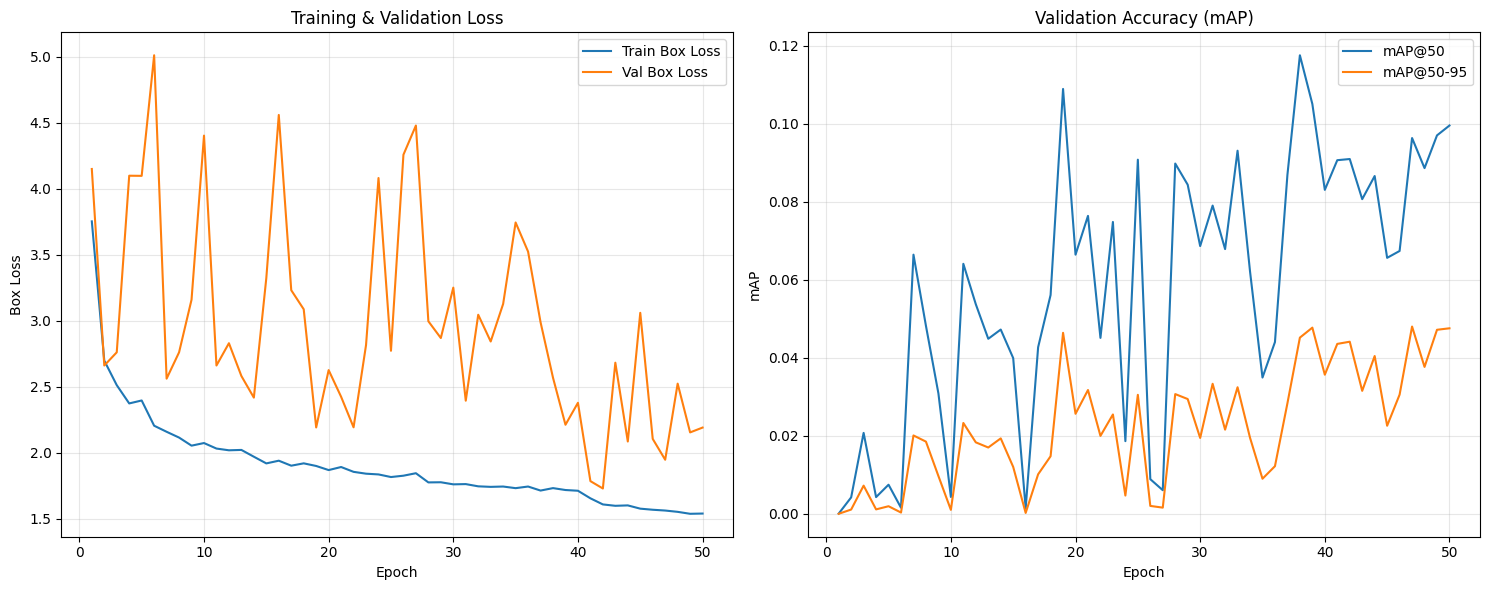

Metrics plotted and saved to /Storage/Files/practicalML/gitlab/practicalml/training_metrics.png
Final mAP@50: 0.09959


In [ ]:
# --- Plot Training Metrics (Accuracy & Loss) ---
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_path = Path('yolo_runs/star_classifier/results.csv')

if results_path.exists():
    # Read CSV (YOLO CSVs have leading spaces in headers)
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    plt.figure(figsize=(15, 6))
    
    # 1. Plot Losses
    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Box Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Plot Accuracy (mAP)
    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50')
    plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95')
    plt.title('Validation Accuracy (mAP)')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_metrics.png')
    plt.show()
    
    print(f"Metrics plotted and saved to {Path('.').absolute() / 'training_metrics.png'}")
    print("Final mAP@50:", df['metrics/mAP50(B)'].iloc[-1])
else:
    print(f"Results file not found at {results_path}. Train the model first.")
